# Sales Growth, Platform GMV & Seasonality Dynamics
**Objective**: Analyze multi-year GMV, monthly order volume, Black Friday seasonal spikes, and revenue trajectory.

C:\Users\Shubham Meena\AppData\Local\Temp\ipykernel_42928\2014681980.py:21: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax1.set_xticklabels(monthly['order_year_month'], rotation=45)


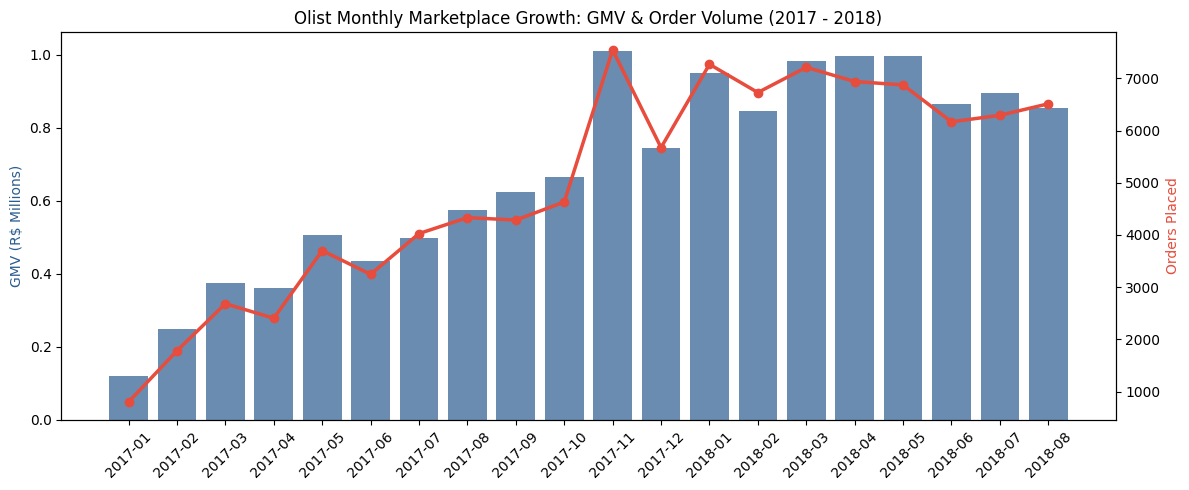

In [1]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

proc_dir = r'../data/processed'
orders = pd.read_csv(os.path.join(proc_dir, 'clean_orders.csv'))

monthly = orders[orders['order_year_month'].between('2017-01', '2018-08')].groupby('order_year_month').agg(
    orders=('order_id', 'count'),
    gmv=('order_subtotal', 'sum'),
    payments=('total_payment_value', 'sum')
).reset_index()

fig, ax1 = plt.subplots(figsize=(12, 5))
ax2 = ax1.twinx()
ax1.bar(monthly['order_year_month'], monthly['gmv']/1e6, color='#2b5c8f', alpha=0.7, label='GMV (R$ Millions)')
ax2.plot(monthly['order_year_month'], monthly['orders'], color='#e74c3c', marker='o', linewidth=2.5, label='Order Volume')
ax1.set_ylabel('GMV (R$ Millions)', color='#2b5c8f')
ax2.set_ylabel('Orders Placed', color='#e74c3c')
ax1.set_xticklabels(monthly['order_year_month'], rotation=45)
plt.title('Olist Monthly Marketplace Growth: GMV & Order Volume (2017 - 2018)')
plt.tight_layout()
plt.show()